# Importing the cleaned Dataset:

In [1]:
import pandas as pd

import pandas as pd
clean_data=pd.read_csv(r"C:\Users\Hi\Desktop\Risk-Analysis\data\processed\ProcessedData.csv")
print("Data Loaded Successfully")

Data Loaded Successfully


In [39]:
pred_data=clean_data.copy()

In [40]:
pred_data.head()

,Patient_ID,Age,Gender,Region,Insurance_Type,Admission_Type,Hospital_Department,Length_of_Stay,Previous_Admissions,Previous_ER_Visits,...,Medication_Count,Lab_Test_Count,Average_Glucose,Systolic_BP,Discharge_Type,Followup_Scheduled,Followup_Attended,Treatment_Cost,Satisfaction_Score,Readmitted_30_Days
0,P100174,70.0,Male,Rift Valley,Employer,Emergency,Diabetes Care,9,4,0,...,6,15,191.6,115,Other,Yes,Yes,131330.0,3.9,No
1,P100275,48.0,Male,Rift Valley,NHIF,Elective,General Medicine,2,0,1,...,8,16,89.9,130,Home with Follow-up,No,No,48495.0,4.8,No
2,P100491,86.0,Male,Nairobi,NHIF,Emergency,Cardiology,3,2,3,...,2,5,129.0,132,Home,No,No,95824.0,3.2,No
3,P100073,51.0,Male,Rift Valley,NHIF,Elective,Orthopedics,6,2,1,...,4,12,126.5,136,Home,Yes,Yes,65729.0,3.6,No
4,P100306,28.0,Male,Central,Cash,Elective,Pediatrics,2,1,3,...,5,5,94.9,109,Home with Follow-up,Yes,No,49791.0,4.6,No


In [46]:
pred_data_1=pred_data.drop(columns=["Patient_ID"])


# Encoding:
X-predictors
Y-Target

In [15]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [48]:
# Encoding categorical variables (y)

label_encoder=LabelEncoder()
categorical_columns=[
    'Readmitted_30_Days',
    
]
for col in categorical_columns:
    pred_data_1[col]=label_encoder.fit_transform(pred_data_1[col])
pred_data_1.head(6)

,Age,Gender,Region,Insurance_Type,Admission_Type,Hospital_Department,Length_of_Stay,Previous_Admissions,Previous_ER_Visits,Diabetes,...,Medication_Count,Lab_Test_Count,Average_Glucose,Systolic_BP,Discharge_Type,Followup_Scheduled,Followup_Attended,Treatment_Cost,Satisfaction_Score,Readmitted_30_Days
0,70.0,Male,Rift Valley,Employer,Emergency,Diabetes Care,9,4,0,Yes,...,6,15,191.6,115,Other,Yes,Yes,131330.0,3.9,0
1,48.0,Male,Rift Valley,NHIF,Elective,General Medicine,2,0,1,No,...,8,16,89.9,130,Home with Follow-up,No,No,48495.0,4.8,0
2,86.0,Male,Nairobi,NHIF,Emergency,Cardiology,3,2,3,Yes,...,2,5,129.0,132,Home,No,No,95824.0,3.2,0
3,51.0,Male,Rift Valley,NHIF,Elective,Orthopedics,6,2,1,No,...,4,12,126.5,136,Home,Yes,Yes,65729.0,3.6,0
4,28.0,Male,Central,Cash,Elective,Pediatrics,2,1,3,No,...,5,5,94.9,109,Home with Follow-up,Yes,No,49791.0,4.6,0
5,42.0,female,Nairobi,Private,Urgent,Orthopedics,3,0,2,Yes,...,4,7,150.8,106,Other,No,No,69935.0,2.2,0


In [50]:
# Encoding categorical variables

label_encoder=LabelEncoder()
categorical_columns = [
    "Gender",
    "Region",
    "Insurance_Type",
    "Admission_Type",
    "Hospital_Department",
    "Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Discharge_Type",
    "Followup_Scheduled",
    "Followup_Attended"
]
for col in categorical_columns:
    pred_data_1[col]=label_encoder.fit_transform(pred_data_1[col])
pred_data_1.head()

,Age,Gender,Region,Insurance_Type,Admission_Type,Hospital_Department,Length_of_Stay,Previous_Admissions,Previous_ER_Visits,Diabetes,...,Medication_Count,Lab_Test_Count,Average_Glucose,Systolic_BP,Discharge_Type,Followup_Scheduled,Followup_Attended,Treatment_Cost,Satisfaction_Score,Readmitted_30_Days
0,70.0,0,5,1,1,1,9,4,0,1,...,6,15,191.6,115,2,1,2,131330.0,3.9,0
1,48.0,0,5,2,0,2,2,0,1,0,...,8,16,89.9,130,1,0,0,48495.0,4.8,0
2,86.0,0,3,2,1,0,3,2,3,1,...,2,5,129.0,132,0,0,0,95824.0,3.2,0
3,51.0,0,5,2,0,3,6,2,1,0,...,4,12,126.5,136,0,1,2,65729.0,3.6,0
4,28.0,0,0,0,0,4,2,1,3,0,...,5,5,94.9,109,1,1,0,49791.0,4.6,0


# Correlation Matrix:

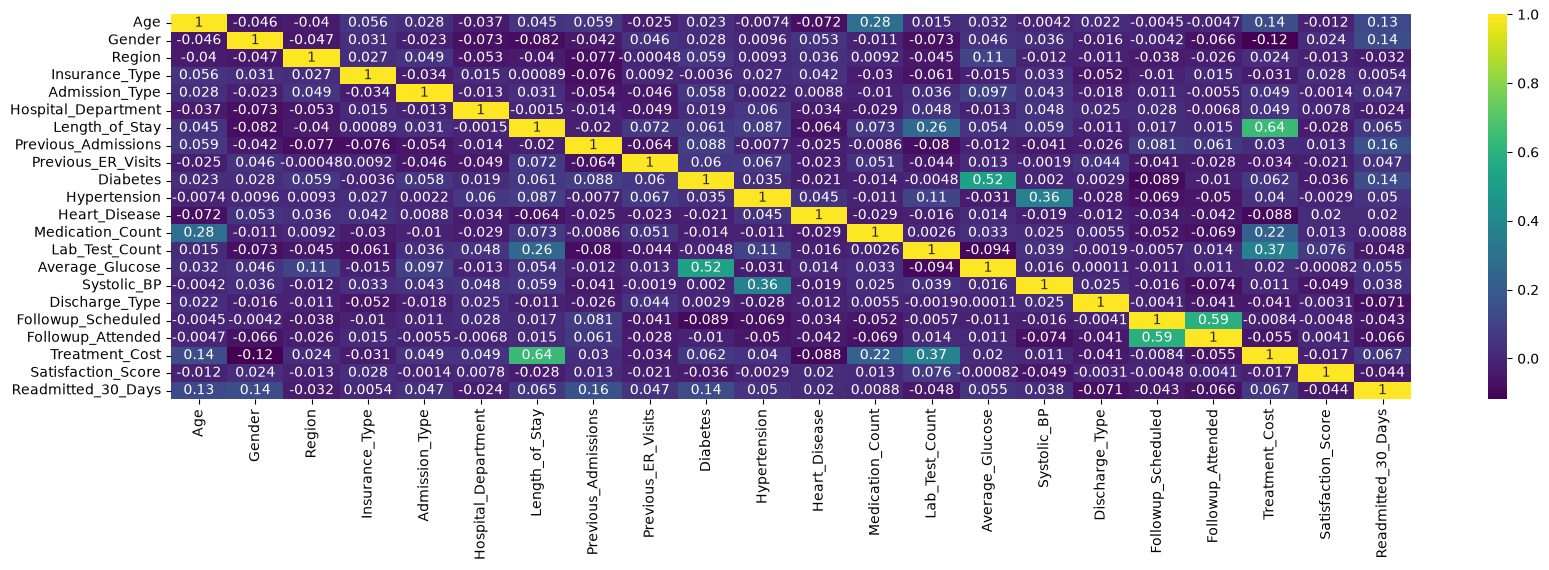

In [55]:
from matplotlib import colors
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (20,5))
sns.heatmap(pred_data_1.corr(),cmap = "viridis",annot = True);

Check Correlation with respect to Readmitted_30_Days

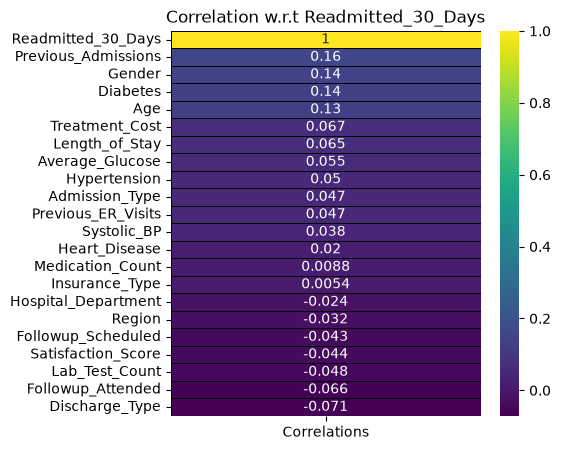

In [57]:
from matplotlib import colors


corr = pred_data_1.corrwith(pred_data_1['Readmitted_30_Days']).sort_values(ascending = False).to_frame()
corr.columns = ['Correlations']
plt.subplots(figsize = (5,5))
sns.heatmap(corr,annot = True,cmap = "viridis",linewidths = 0.4,linecolor = 'black');
plt.title('Correlation w.r.t Readmitted_30_Days');


# Feature Selection for Categorical Features:

Chi-Square test


Categorical and numerical features:

In [60]:
categorical_features = [
    "Gender",
    "Region",
    "Insurance_Type",
    "Admission_Type",
    "Hospital_Department",
    "Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Discharge_Type",
    "Followup_Scheduled",
    "Followup_Attended"
]

In [61]:
numerical_features = [
    "Age",
    "Length_of_Stay",
    "Previous_Admissions",
    "Previous_ER_Visits",
    "Medication_Count",
    "Lab_Test_Count",
    "Average_Glucose",
    "Systolic_BP",
    "Treatment_Cost",
    "Satisfaction_Score"
]

Text(0.5, 1.0, 'Selection of Categorical Features')

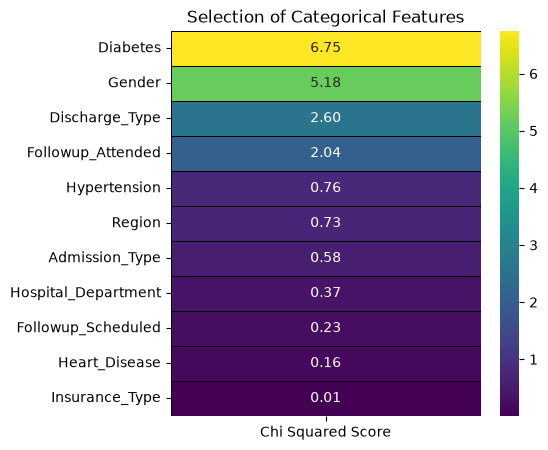

In [69]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
pd.options.display.float_format = '{:.2f}'.format


best_features = SelectKBest(score_func = chi2,k = 'all')
features = pred_data_1[categorical_features]
target = pred_data_1["Readmitted_30_Days"]


fit = best_features.fit(features, target)

featureScores = pd.DataFrame(
    {"Chi Squared Score": fit.scores_},
    index=features.columns
)

plt.subplots(figsize=(5, 5))
sns.heatmap(
    featureScores.sort_values(
        by="Chi Squared Score",
        ascending=False
    ),
    annot=True,
    cmap="viridis",
    linewidths=0.4,
    linecolor="black",
    fmt=".2f"
)
plt.title("Selection of Categorical Features")



# Feature Selection for Numerical features:

Anova test


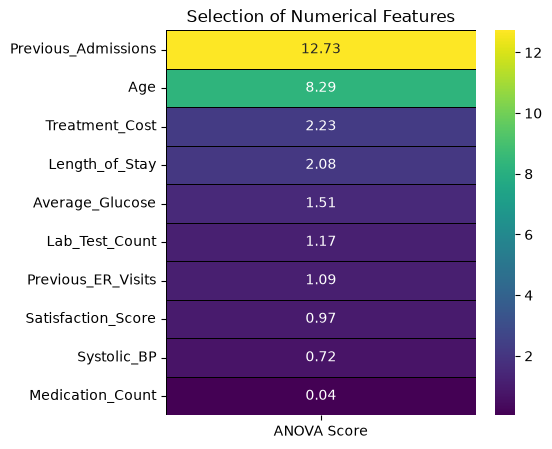

In [66]:
from sklearn.feature_selection import f_classif

features = pred_data_1[numerical_features]
target = pred_data_1["Readmitted_30_Days"]

best_features = SelectKBest(score_func = f_classif,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['ANOVA Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'ANOVA Score'),annot = True,cmap = 'viridis',linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Numerical Features');

# Modelling

In [70]:
from sklearn.model_selection import train_test_split
features = pred_data_1[pred_data_1.columns.drop(['Readmitted_30_Days'])].values
target = pred_data_1['Readmitted_30_Days'].values
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state = 2)

In [71]:
from sklearn.model_selection import train_test_split

# splitting dataset into training and test variables
X_train, X_test, y_train, y_test=train_test_split(features,target,test_size=0.2, random_state=42)

In [75]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
pd.options.display.float_format = '{:.2f}'.format

def model(classifier):
    
    classifier.fit(X_train,y_train)
    prediction = classifier.predict(X_test)
    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Accuracy : ",'{0:.2%}'.format(accuracy_score(y_test,prediction)))
    print("Cross Validation Score : ",'{0:.2%}'.format(cross_val_score(classifier,X_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.2%}'.format(roc_auc_score(y_test,prediction)))
    RocCurveDisplay.from_estimator(classifier, X_test, y_test)
    plt.title('ROC_AUC_Plot')
    plt.show()

def model_evaluation(classifier):
    
    # Confusion Matrix
    cm = confusion_matrix(y_test,classifier.predict(X_test))
    names = ['True Neg','False Pos','False Neg','True Pos']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm,annot = labels,cmap = "viridis",fmt ='')
    
    # Classification Report
    print(classification_report(y_test,classifier.predict(X_test)))

1. Logistics Regression


In [76]:
from sklearn.linear_model import LogisticRegression
classifier_lr = LogisticRegression(random_state = 0,C=10,penalty= 'l2') 

C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

Accuracy :  75.00%


C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 

Cross Validation Score :  52.95%
ROC_AUC Score :  50.00%


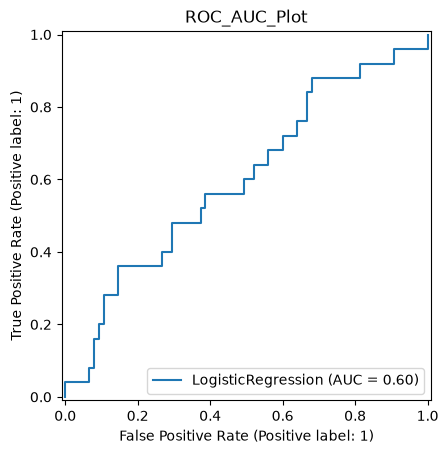

In [77]:
model(classifier_lr)

              precision    recall  f1-score   support

           0       0.75      1.00      0.86        75
           1       0.00      0.00      0.00        25

    accuracy                           0.75       100
   macro avg       0.38      0.50      0.43       100
weighted avg       0.56      0.75      0.64       100



C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

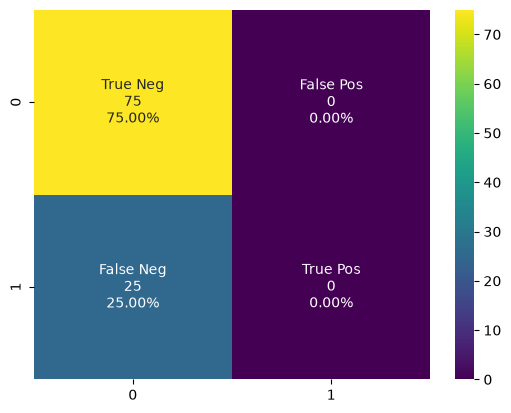

In [78]:
model_evaluation(classifier_lr)

2. Support vector classifier:

In [79]:
from sklearn.svm import SVC
classifier_svc = SVC(kernel = 'linear',C = 0.1)

In [ ]:
model(classifier_svc)

Accuracy :  75.00%


In [1]:
model_evaluation(classifier_svc)

NameError: name 'model_evaluation' is not defined

3. Decision Trees Classifier:

In [4]:
from sklearn.tree import DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(random_state = 1000,max_depth = 4,min_samples_leaf = 1)

In [6]:
model(classifier_dt)

NameError: name 'model' is not defined